# Exploratory Data Analysis and Data Preprocessing
**Project:** Complaint-analysis-chatbot-RAG

**Objective:** Understand the structure, content, and quality of the CFPB
consumer complaint data, then filter and clean it so it's ready to feed
into the chunking or embedding pipeline.

This notebook:
1. Loads the full CFPB complaint dataset.
2. Explores product distribution, narrative length, and narrative
   availability.
3. Filters the data down to (Credit Card, Personal Loan, Savings Account, Money Transfer) and
   drops complaints with no narrative.
4. Cleans the narrative text (lowercasing, boilerplate removal, special
   character stripping, CFPB redaction-token removal).
5. Saves the cleaned, filtered dataset to `data/filtered_complaints.csv`

1. Load the CFPB Dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/complaints.csv")

print(df.shape)
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_12376\2675233770.py:3: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


(9609797, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


2. Inspect Data Quality

In [93]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 20 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
 18  has_narrative                 bool 
 19  word_count                    in

Date received                         0
Product                               0
Sub-product                      235295
Issue                                 6
Sub-issue                        839522
Consumer complaint narrative    6629041
Company public response         4770207
Company                               0
State                             54516
ZIP code                          30228
Tags                            8981029
Consumer consent provided?      1649561
Submitted via                         0
Date sent to company                  0
Company response to consumer         20
Timely response?                      0
Consumer disputed?              8841498
Complaint ID                          0
has_narrative                         0
word_count                            0
dtype: int64

## 3. Exploratory Data Analysis

### 3.1 Distribution of complaints across products

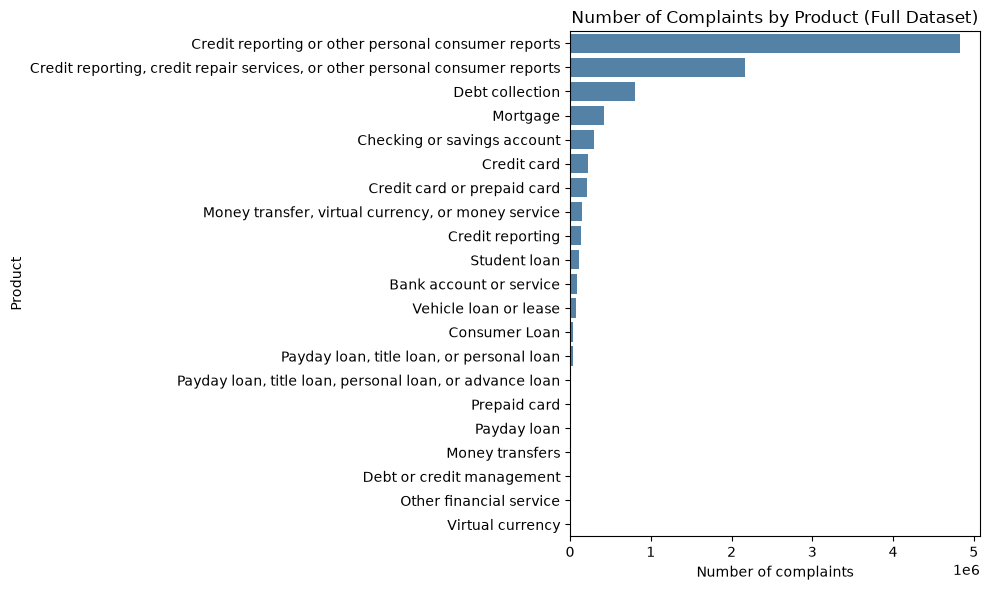

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

product_counts = df["Product"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.values, y=product_counts.index, color="steelblue")
plt.title("Number of Complaints by Product (Full Dataset)")
plt.xlabel("Number of complaints")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 4. Narrative Availability
We compute word count only over complaints that *have* a narrative —
length is undefined for missing narratives. We look at the distribution
and flag unusually short and unusually long entries.

In [95]:
df["has_narrative"] = (
    df["Consumer complaint narrative"]
    .notna()
)

df["has_narrative"].value_counts()

has_narrative
False    6629041
True     2980756
Name: count, dtype: int64

### 4.1 Complaints with vs. without a narrative

Overall, and broken down by product — some products may have much
sparser narrative coverage than others, which matters for the RAG
pipeline since only narratives are embedded.

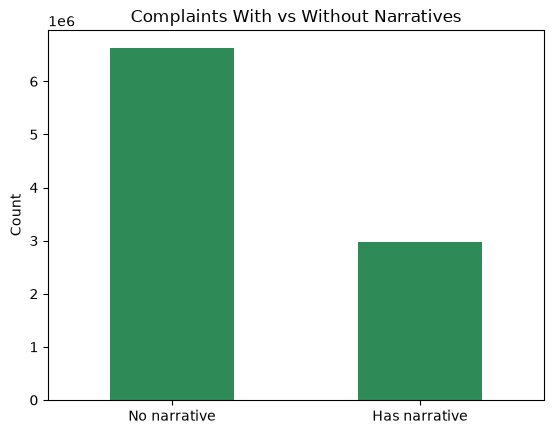

In [96]:
narrative_counts = df["has_narrative"].value_counts()
narrative_counts.index = ["Has narrative" if x else "No narrative" for x in narrative_counts.index]

narrative_counts.plot(
    kind="bar",
    color="seagreen"
)

plt.title("Complaints With vs Without Narratives")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

5. Narrative Length Analysis

In [97]:
has_narrative_mask = df["Consumer complaint narrative"].notna()

word_counts = (
    df.loc[has_narrative_mask, "Consumer complaint narrative"]
      .str.count(r"\S+")
)

print(word_counts.describe())

SHORT_THRESHOLD = 5
LONG_THRESHOLD = word_counts.quantile(0.99)

n_short = (word_counts < SHORT_THRESHOLD).sum()
n_long = (word_counts > LONG_THRESHOLD).sum()

print(
    f"\nComplaints with fewer than {SHORT_THRESHOLD} words: "
    f"{n_short:,} ({n_short / len(word_counts):.2%} of narratives)"
)

print(
    f"Complaints longer than the 99th percentile "
    f"({LONG_THRESHOLD:.0f} words): "
    f"{n_long:,} ({n_long / len(word_counts):.2%} of narratives)"
)

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: Consumer complaint narrative, dtype: float64

Complaints with fewer than 5 words: 3,175 (0.11% of narratives)
Complaints longer than the 99th percentile (1021 words): 29,124 (0.98% of narratives)


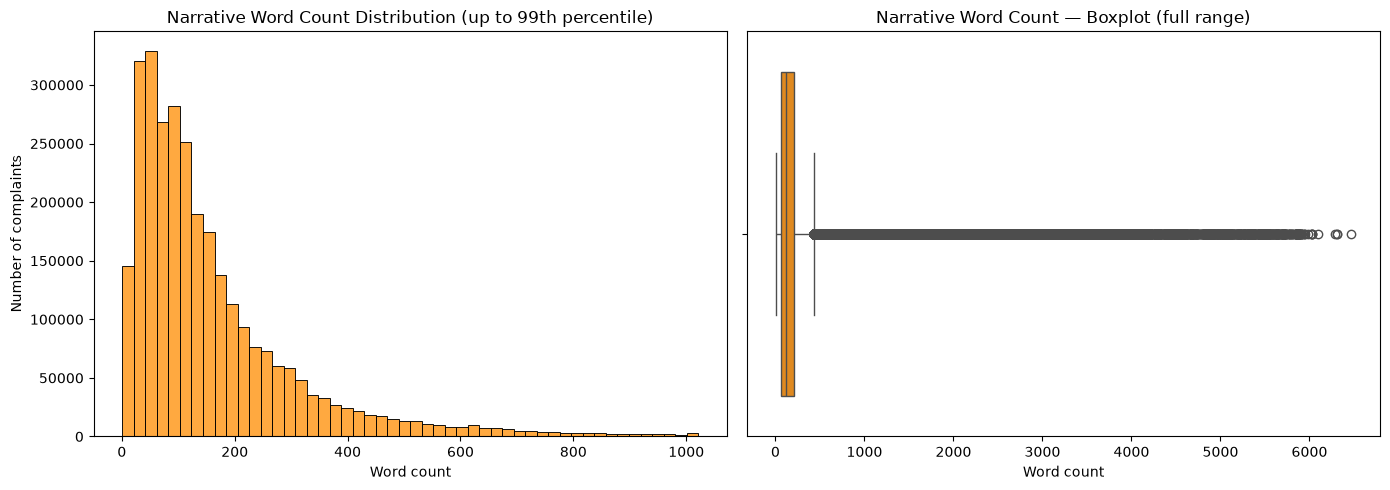

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(word_counts[word_counts <= word_counts.quantile(0.99)], bins=50, ax=axes[0], color="darkorange")
axes[0].set_title("Narrative Word Count Distribution (up to 99th percentile)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of complaints")

sns.boxplot(x=word_counts, ax=axes[1], color="darkorange")
axes[1].set_title("Narrative Word Count — Boxplot (full range)")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()

6. Filter Required Products
We need exactly four product categories: **Credit Card, Personal Loan,
Savings Account, Money Transfer**.

In [99]:
product_mapping = {
    # Credit Cards
    "Credit card": "Credit Card",
    "Credit card or prepaid card": "Credit Card",

    # Personal Loans
    "Consumer Loan": "Personal Loan",
    "Payday loan": "Personal Loan",
    "Payday loan, title loan, or personal loan": "Personal Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Personal Loan",

    # Savings Accounts
    "Bank account or service": "Savings Account",
    "Checking or savings account": "Savings Account",

    # Money Transfers
    "Money transfers": "Money Transfer",
    "Money transfer, virtual currency, or money service": "Money Transfer"
}

In [100]:
filtered_df = df[
    df["Product"].isin(product_mapping.keys())
].copy()

filtered_df["product_category"] = (
    filtered_df["Product"].map(product_mapping)
)

In [102]:
filtered_df["product_category"].value_counts()

product_category
Credit Card        433055
Savings Account    377383
Money Transfer     150420
Personal Loan       84270
Name: count, dtype: int64

7. Remove Missing Narratives

In [103]:
filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"]
    .notna()
]

filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"]
    .str.strip()
    .ne("")
]

In [104]:
before = len(filtered_df)

filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].notna()
]

filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].str.strip() != ""
]

after = len(filtered_df)

print(f"Removed {before - after:,} records with missing narratives")
print(f"Remaining records: {after:,}")

Removed 0 records with missing narratives
Remaining records: 480,564


In [105]:
print(filtered_df.shape)

(480564, 21)


In [106]:
filtered_df["Consumer complaint narrative"].str.len().describe()

count    480564.000000
mean       1140.785818
std        1250.828947
min           4.000000
25%         466.000000
50%         752.000000
75%        1402.000000
max       32959.000000
Name: Consumer complaint narrative, dtype: float64

In [107]:
filtered_df["Consumer complaint narrative"].isna().sum()

np.int64(0)

In [108]:
(filtered_df["Consumer complaint narrative"].str.strip() == "").sum()

np.int64(0)

8. Text Cleaning

In [109]:
import re
import pandas as pd
import numpy as np

BOILERPLATE_PATTERNS = [
    r"^dear cfpb,?\s*",
    r"^to whom it may concern,?\s*",
    r"^dear (sir|madam|sir/madam),?\s*",

    r"^i am writing to file a complaint regarding\s*",
    r"^i am writing to file a complaint about\s*",
    r"^i am writing to file a formal complaint about\s*",

    r"^i would like to file a (formal )?complaint (about|regarding)\s*",
    r"^i am filing this complaint (against|about|regarding)\s*",

    r"^this complaint is (in regards|regarding) to\s*",
    r"^this is regarding\s*",

    r"^i am writing to dispute (the following )?\s*"
]

def clean_narrative(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # remove CFPB redaction patterns
    text = re.sub(r"x{2,}[/\-]x{2,}[/\-]\d{2,4}", " ", text)
    text = re.sub(r"\bx{2,}\b", " ", text)

    text = re.sub(r"^b['\"]", "", text)

    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # remove boilerplate openings
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, "", text, count=1)

    # remove special characters
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # normalize whitespace (IMPORTANT)
    text = re.sub(r"\s+", " ", text).strip()

    return text


# apply cleaning
filtered_df["cleaned_narrative"] = filtered_df["Consumer complaint narrative"].apply(clean_narrative)

# remove empty results after cleaning
empty_after_clean = (filtered_df["cleaned_narrative"].str.len() == 0).sum()
df_filtered = filtered_df[filtered_df["cleaned_narrative"].str.len() > 0].copy()

print(f"Dropped {empty_after_clean:,} empty rows after cleaning")
print(f"Final row count: {len(df_filtered):,}")

Dropped 4 empty rows after cleaning
Final row count: 480,560


In [111]:
filtered_df[["Consumer complaint narrative", "cleaned_narrative"]].head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...",i have a secured credit card with citibank whi...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,charges on my citi credit card accounts where ...


In [112]:
filtered_df = filtered_df[
    filtered_df["cleaned_narrative"].str.strip() != ""
]

In [114]:
filtered_df.to_csv("../data/processed/filtered_complaints.csv", index=False)

In [117]:
# Constants matching project guidelines
SHORT_THRESHOLD = 5
LONG_THRESHOLD = 1000

# Explicitly ensure the output path variable is defined in this session context
FILTERED_OUTPUT_PATH = "../data/filtered_complaints.csv"

# Compute base variables directly from your dataframe state
product_counts = df['Product'].value_counts()
top_product = product_counts.index[0]
top_product_share = product_counts.iloc[0] / product_counts.sum()

# Check for narrative presence mapping (adapting to standard columns)
if 'has_narrative' in df.columns:
    overall_narrative_share = df['has_narrative'].sum() / len(df)
else:
    overall_narrative_share = df['Consumer complaint narrative'].notna().sum() / len(df)

# Use correct word count column names from your notebook's previous processing cells
word_count_col = 'word_count' if 'word_count' in filtered_df.columns else 'narrative_word_count'
median_words = filtered_df[word_count_col].median()

# Dynamic count criteria for short/long threshold categories
n_short = (filtered_df[word_count_col] <= SHORT_THRESHOLD).sum()
n_long = (filtered_df[word_count_col] > LONG_THRESHOLD).sum()

# Safe fallback definition for empty row calculations if not previously assigned
if 'empty_after_clean' not in locals() and 'empty_after_clean' not in globals():
    empty_after_clean = 0

summary = f"""
**EDA Summary**
The full CFPB complaint dataset contains {len(df):,} records across {df['Product'].nunique()} \
product categories. The most frequent product is "{top_product}", accounting for \
{top_product_share:.1%} of all complaints, while the remaining products are more evenly spread. \
Overall, {overall_narrative_share:.1%} of complaints include a free-text consumer narrative; \
narrative availability varies noticeably by product, which matters for the \
RAG pipeline since only narratives are embedded and retrievable.

Among complaints that do include a narrative, the median length is {median_words:.0f} words, with a \
distribution that is right-skewed: most narratives sit in a moderate range, but a small share \
({n_short:,} complaints, {n_short / len(filtered_df):.1%}) are extremely short (under {SHORT_THRESHOLD} \
words) and convey little usable information, while another small share ({n_long:,} complaints, \
{n_long / len(filtered_df):.1%}) exceed {LONG_THRESHOLD:.0f} words and may need to be split across \
multiple chunks during embedding.

After restricting the data to the four products CrediTrust cares about (Credit Card, Personal \
Loan, Savings Account, Money Transfer) and dropping complaints with no narrative, the filtered \
dataset contains {len(filtered_df):,} records ({len(filtered_df) / len(df):.1%} of the original \
data). Text cleaning (lowercasing, removal of CFPB's redaction placeholders and boilerplate \
complaint openers, and stripping of special characters) was applied to produce a `cleaned_narrative` \
column, with {empty_after_clean} rows dropped for becoming empty after cleaning. The result is saved \
to `{FILTERED_OUTPUT_PATH}` and is ready for chunking and embedding in Task 2.
"""

print(summary)


**EDA Summary**
The full CFPB complaint dataset contains 9,609,797 records across 21 product categories. The most frequent product is "Credit reporting or other personal consumer reports", accounting for 50.3% of all complaints, while the remaining products are more evenly spread. Overall, 31.0% of complaints include a free-text consumer narrative; narrative availability varies noticeably by product, which matters for the RAG pipeline since only narratives are embedded and retrievable.

Among complaints that do include a narrative, the median length is 137 words, with a distribution that is right-skewed: most narratives sit in a moderate range, but a small share (485 complaints, 0.1%) are extremely short (under 5 words) and convey little usable information, while another small share (5,409 complaints, 1.1%) exceed 1000 words and may need to be split across multiple chunks during embedding.

After restricting the data to the four products CrediTrust cares about (Credit Card, Personal L